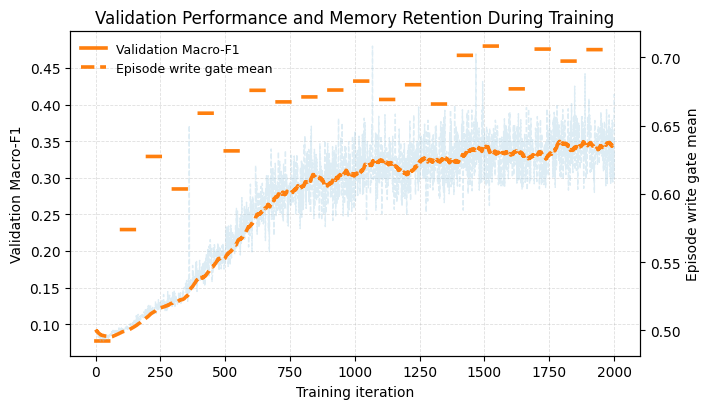

Saved: pc_dlcmnet_figures_hybrid/fig1_val_macro_f1_vs_memory_gate.png


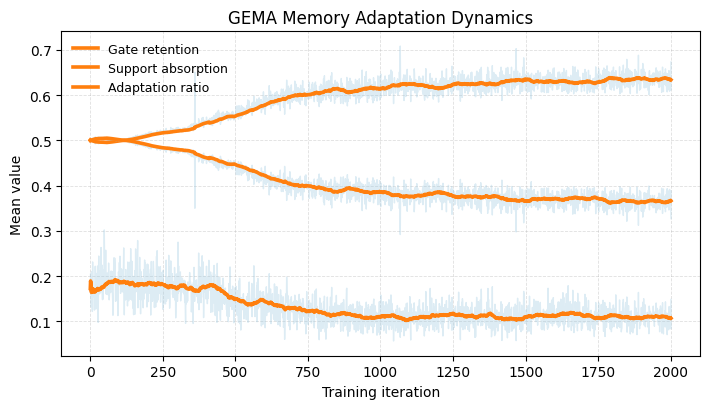

Saved: pc_dlcmnet_figures_hybrid/fig2_gema_adaptation_dynamics.png


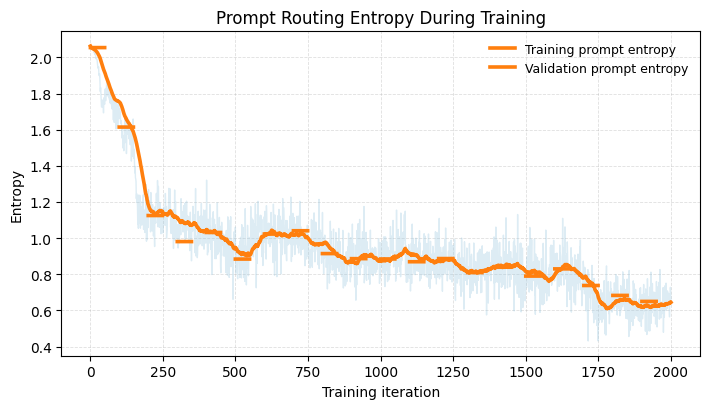

Saved: pc_dlcmnet_figures_hybrid/fig3_prompt_route_entropy.png


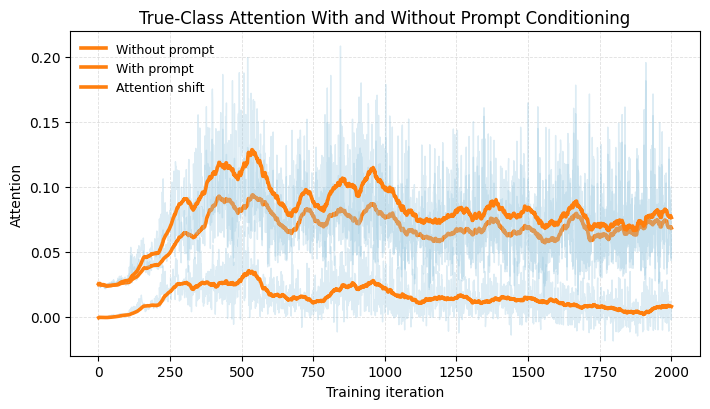

Saved: pc_dlcmnet_figures_hybrid/fig4_true_class_attention.png


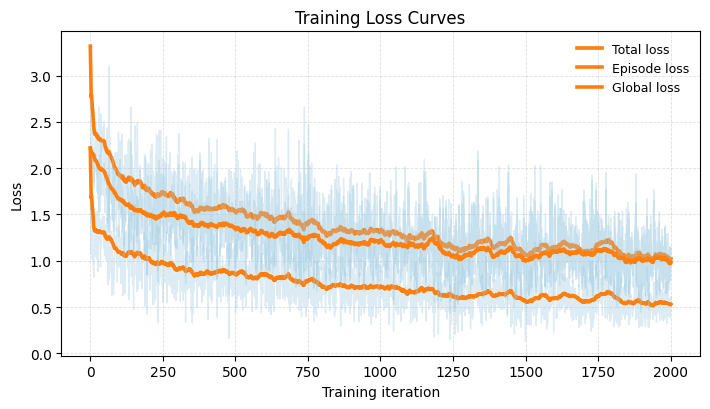

Saved: pc_dlcmnet_figures_hybrid/fig5_training_losses.png
Saved processed CSV: pc_dlcmnet_figures_hybrid/processed_training_log_with_means.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# 1. Configuration
# =========================

INPUT_CSV = Path("/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/mechanism_qingyang/result.curve.csv")   # 改成你的日志路径
OUTPUT_DIR = Path("pc_dlcmnet_figures_hybrid")

SMOOTH_WINDOW = 50     # 平滑窗口，可以改成 15 / 25 / 50
DPI = 300
FIGSIZE = (7.2, 4.2)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 2. Load data
# =========================

df = pd.read_csv(INPUT_CSV)

# 尽量把所有列转成数值，无法转换的变成 NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 优先使用 step 作为横轴；如果没有 step，就使用 epoch
x_col = "step" if "step" in df.columns else "epoch"

df = df.sort_values(x_col).reset_index(drop=True)


# =========================
# 3. Utility functions
# =========================

def smooth_series(series, window=SMOOTH_WINDOW):
    """
    Rolling mean smoothing.
    这里只用于画趋势线，不改变原始数据。
    """
    return series.rolling(window=window, min_periods=1).mean()


def add_raw_and_smooth_line(
    ax,
    x,
    y,
    label,
    linestyle="-",
    raw_color="#9ecae1",       # 浅蓝色原始波动
    smooth_color="#ff7f0e",    # 橙色平滑主线
    raw_alpha=0.35,
    raw_lw=1.0,
    smooth_lw=2.6
):
    """
    同一指标画两条线：
    1. 原始值：浅蓝色细线，不进图例
    2. 平滑值：橙色粗线，进入图例

    图例只显示一次 label。
    """

    # 原始值：浅蓝色浮动
    ax.plot(
        x,
        y,
        linewidth=raw_lw,
        alpha=raw_alpha,
        linestyle=linestyle,
        color=raw_color,
        label="_nolegend_"
    )

    # 平滑值：橙色主线
    line_smooth, = ax.plot(
        x,
        smooth_series(y),
        linewidth=smooth_lw,
        alpha=1.0,
        linestyle=linestyle,
        color=smooth_color,
        label=label
    )

    return line_smooth


def format_axis(ax, xlabel="Training iteration", ylabel=None, title=None):
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
    ax.tick_params(axis="both", labelsize=10)


def save_fig(fig, filename):
    out_path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")
    plt.close(fig)


def make_single_axis_plot(columns, labels, title, ylabel, filename):
    """
    用于普通单 y 轴折线图。
    """
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for col, label in zip(columns, labels):
        if col in df.columns and df[col].notna().sum() > 0:
            add_raw_and_smooth_line(
                ax=ax,
                x=df[x_col],
                y=df[col],
                label=label
            )
        else:
            print(f"Warning: column not found or empty: {col}")

    format_axis(
        ax=ax,
        xlabel="Training iteration",
        ylabel=ylabel,
        title=title
    )

    ax.legend(frameon=False, fontsize=9)
    save_fig(fig, filename)
    plt.close(fig)


def make_dual_axis_plot(left_col, right_col, left_label, right_label,
                        title, left_ylabel, right_ylabel, filename):
    """
    用于双 y 轴折线图。
    """
    fig, ax_left = plt.subplots(figsize=FIGSIZE)
    ax_right = ax_left.twinx()

    lines = []

    if left_col in df.columns and df[left_col].notna().sum() > 0:
        line_left = add_raw_and_smooth_line(
            ax=ax_left,
            x=df[x_col],
            y=df[left_col],
            label=left_label,
            linestyle="-"
        )
        lines.append(line_left)
    else:
        print(f"Warning: column not found or empty: {left_col}")

    if right_col in df.columns and df[right_col].notna().sum() > 0:
        line_right = add_raw_and_smooth_line(
            ax=ax_right,
            x=df[x_col],
            y=df[right_col],
            label=right_label,
            linestyle="--"
        )
        lines.append(line_right)
    else:
        print(f"Warning: column not found or empty: {right_col}")

    format_axis(
        ax=ax_left,
        xlabel="Training iteration",
        ylabel=left_ylabel,
        title=title
    )
    ax_right.set_ylabel(right_ylabel)
    ax_right.tick_params(axis="y", labelsize=10)

    ax_left.legend(
        handles=lines,
        labels=[line.get_label() for line in lines],
        frameon=False,
        fontsize=9,
        loc="best"
    )

    save_fig(fig, filename)
    plt.close(fig)


# =========================
# 4. Derive class-level means
# =========================

def add_mean_column(prefix, new_col):
    """
    例如：
    gate_retention_class_0 ... gate_retention_class_8
    取平均后得到 mean_gate_retention
    """
    cols = [col for col in df.columns if col.startswith(prefix)]

    if len(cols) == 0:
        print(f"Warning: no columns found with prefix: {prefix}")
        return

    df[new_col] = df[cols].mean(axis=1)


add_mean_column("gate_retention_class_", "mean_gate_retention")
add_mean_column("support_absorption_class_", "mean_support_absorption")
add_mean_column("adaptation_ratio_class_", "mean_adaptation_ratio")


# =========================
# 5. Figure 1
# Validation Macro-F1 + Memory Gate
# =========================

make_dual_axis_plot(
    left_col="val_macro_f1",
    right_col="episode_write_gate_mean",
    left_label="Validation Macro-F1",
    right_label="Episode write gate mean",
    title="Validation Performance and Memory Retention During Training",
    left_ylabel="Validation Macro-F1",
    right_ylabel="Episode write gate mean",
    filename="fig1_val_macro_f1_vs_memory_gate.png"
)


# =========================
# 6. Figure 2
# GEMA Memory Adaptation Dynamics
# =========================

make_single_axis_plot(
    columns=[
        "mean_gate_retention",
        "mean_support_absorption",
        "mean_adaptation_ratio"
    ],
    labels=[
        "Gate retention",
        "Support absorption",
        "Adaptation ratio"
    ],
    title="GEMA Memory Adaptation Dynamics",
    ylabel="Mean value",
    filename="fig2_gema_adaptation_dynamics.png"
)


# =========================
# 7. Figure 3
# Prompt Routing Entropy
# =========================

make_single_axis_plot(
    columns=[
        "prompt_route_entropy",
        "val_prompt_route_entropy"
    ],
    labels=[
        "Training prompt entropy",
        "Validation prompt entropy"
    ],
    title="Prompt Routing Entropy During Training",
    ylabel="Entropy",
    filename="fig3_prompt_route_entropy.png"
)


# =========================
# 8. Figure 4
# True-Class Attention
# =========================

make_single_axis_plot(
    columns=[
        "true_attention_without_prompt",
        "true_attention_with_prompt",
        "true_attention_shift"
    ],
    labels=[
        "Without prompt",
        "With prompt",
        "Attention shift"
    ],
    title="True-Class Attention With and Without Prompt Conditioning",
    ylabel="Attention",
    filename="fig4_true_class_attention.png"
)


# =========================
# 9. Figure 5
# Training Loss Curves
# =========================

make_single_axis_plot(
    columns=[
        "train_loss",
        "train_episode_loss",
        "train_global_loss"
    ],
    labels=[
        "Total loss",
        "Episode loss",
        "Global loss"
    ],
    title="Training Loss Curves",
    ylabel="Loss",
    filename="fig5_training_losses.png"
)


# =========================
# 10. Optional: save processed CSV
# =========================

processed_csv = OUTPUT_DIR / "processed_training_log_with_means.csv"
df.to_csv(processed_csv, index=False)
print(f"Saved processed CSV: {processed_csv}")

Saved figure to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_prompt_distribution_over_iterations_ieee_inside_legend.png


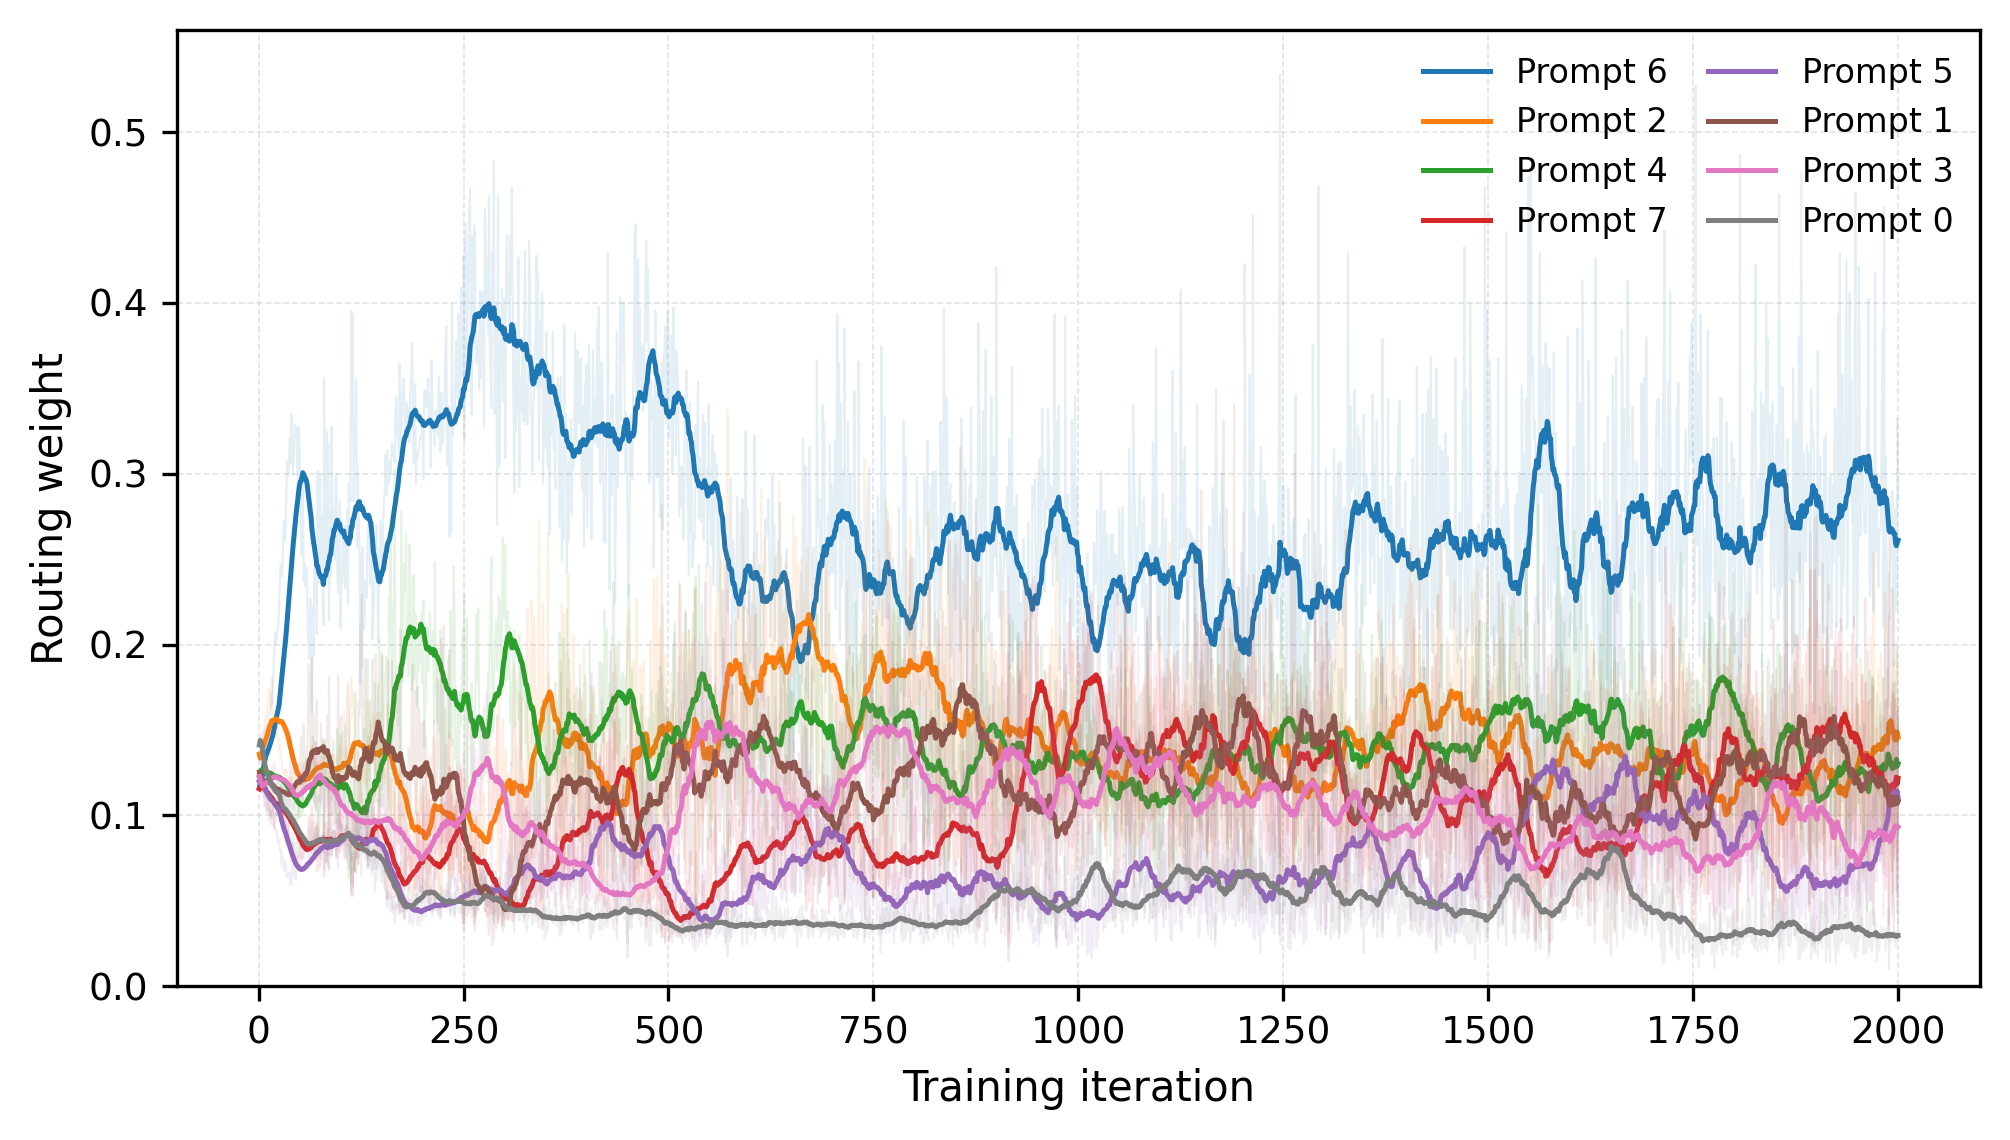

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# 1. Configuration
# =========================

INPUT_CSV = Path("/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/mechanism_qingyang/result.curve.csv")
OUTPUT_DIR = Path("/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 平滑窗口
SMOOTH_WINDOW = 25

# 画图参数
DPI = 300
FIGSIZE = (6.8, 3.9)   # 适合双栏论文宽度
RAW_ALPHA = 0.12       # 原始数据透明度
RAW_LW = 0.5           # 原始数据线宽
SMOOTH_LW = 1.2        # 平滑曲线线宽

# 是否显示图
SHOW_FIG = True


# =========================
# 2. Load data
# =========================

df = pd.read_csv(INPUT_CSV)

# 尽量转为数值
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 横轴优先使用 step
x_col = "step" if "step" in df.columns else "epoch"

df = df.sort_values(x_col).reset_index(drop=True)


# =========================
# 3. Get prompt columns
# =========================

prompt_cols = []
for i in range(8):
    col = f"prompt_route_mean_{i}"
    if col in df.columns:
        prompt_cols.append(col)

if len(prompt_cols) == 0:
    raise ValueError("No prompt_route_mean_* columns found in the CSV file.")


# =========================
# 4. Smoothing function
# =========================

def smooth_series(series, window=SMOOTH_WINDOW):
    return series.rolling(window=window, min_periods=1).mean()


# =========================
# 5. Decide plotting order
#    （按最终平滑值从大到小排序）
# =========================

final_smoothed_values = {}
for col in prompt_cols:
    final_smoothed_values[col] = smooth_series(df[col]).iloc[-1]

ordered_prompt_cols = sorted(
    prompt_cols,
    key=lambda c: final_smoothed_values[c],
    reverse=True
)


# =========================
# 6. Plot
# =========================

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

for col in ordered_prompt_cols:
    prompt_id = col.split("_")[-1]

    # 先画原始值：浅色细线，不进图例
    raw_line, = ax.plot(
        df[x_col],
        df[col],
        linewidth=RAW_LW,
        alpha=RAW_ALPHA,
        label="_nolegend_"
    )

    # 获取当前颜色，保证原始值和平滑值同色系
    color = raw_line.get_color()

    # 再画平滑值：主线，进入图例
    ax.plot(
        df[x_col],
        smooth_series(df[col]),
        linewidth=SMOOTH_LW,
        color=color,
        label=f"Prompt {prompt_id}"
    )


# =========================
# 7. Axis style (IEEE-like)
# =========================

# 不加大标题，论文里一般由 caption 说明
ax.set_xlabel("Training iteration", fontsize=10)
ax.set_ylabel("Routing weight", fontsize=10)

ax.tick_params(axis="both", labelsize=9)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.4,
    alpha=0.35
)

# 可选：限制 y 轴范围
ax.set_ylim(bottom=0)

# 图例放在图里面
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=2,
    loc="upper right",   # 图例在图里面；如果挡住曲线，可改成 "lower right" / "best"
    handlelength=2.0,
    columnspacing=1.2,
    borderaxespad=0.4
)

fig.tight_layout()


# =========================
# 8. Save and show
# =========================

output_path = OUTPUT_DIR / "fig_prompt_distribution_over_iterations_ieee_inside_legend.png"
fig.savefig(output_path, bbox_inches="tight")
print(f"Saved figure to: {output_path.resolve()}")

if SHOW_FIG:
    plt.show()

plt.close(fig)

Saved figure to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_prompt_distribution_over_iterations_2x4_regions_clean.jpg


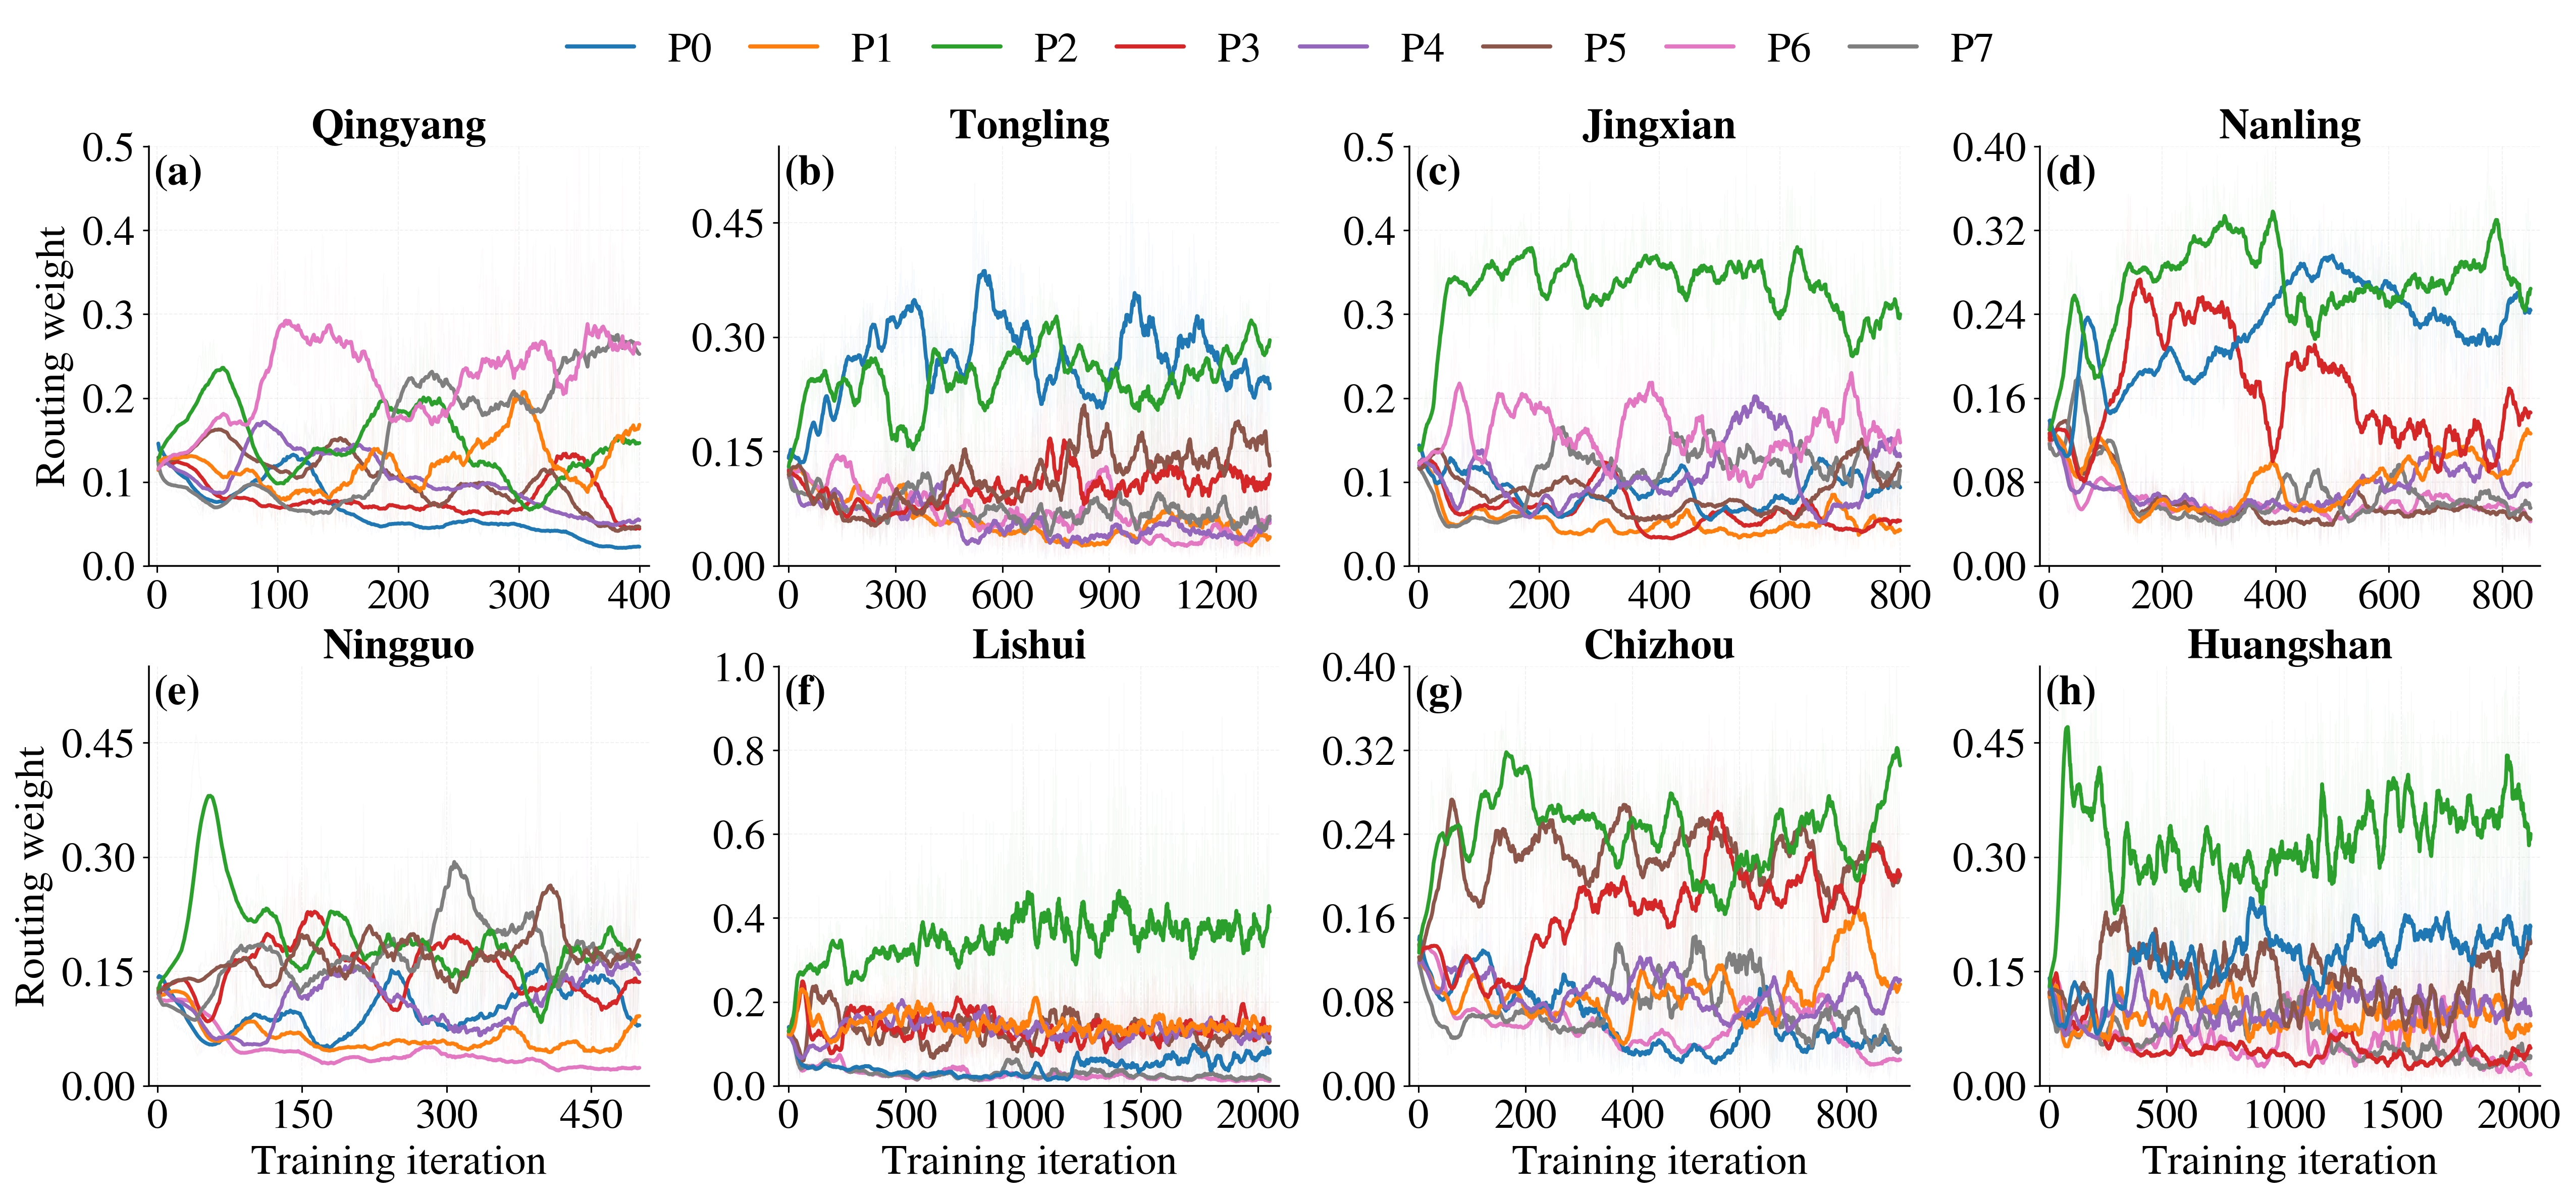

Saved figure to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_episode_memory_dense_paper_style.png


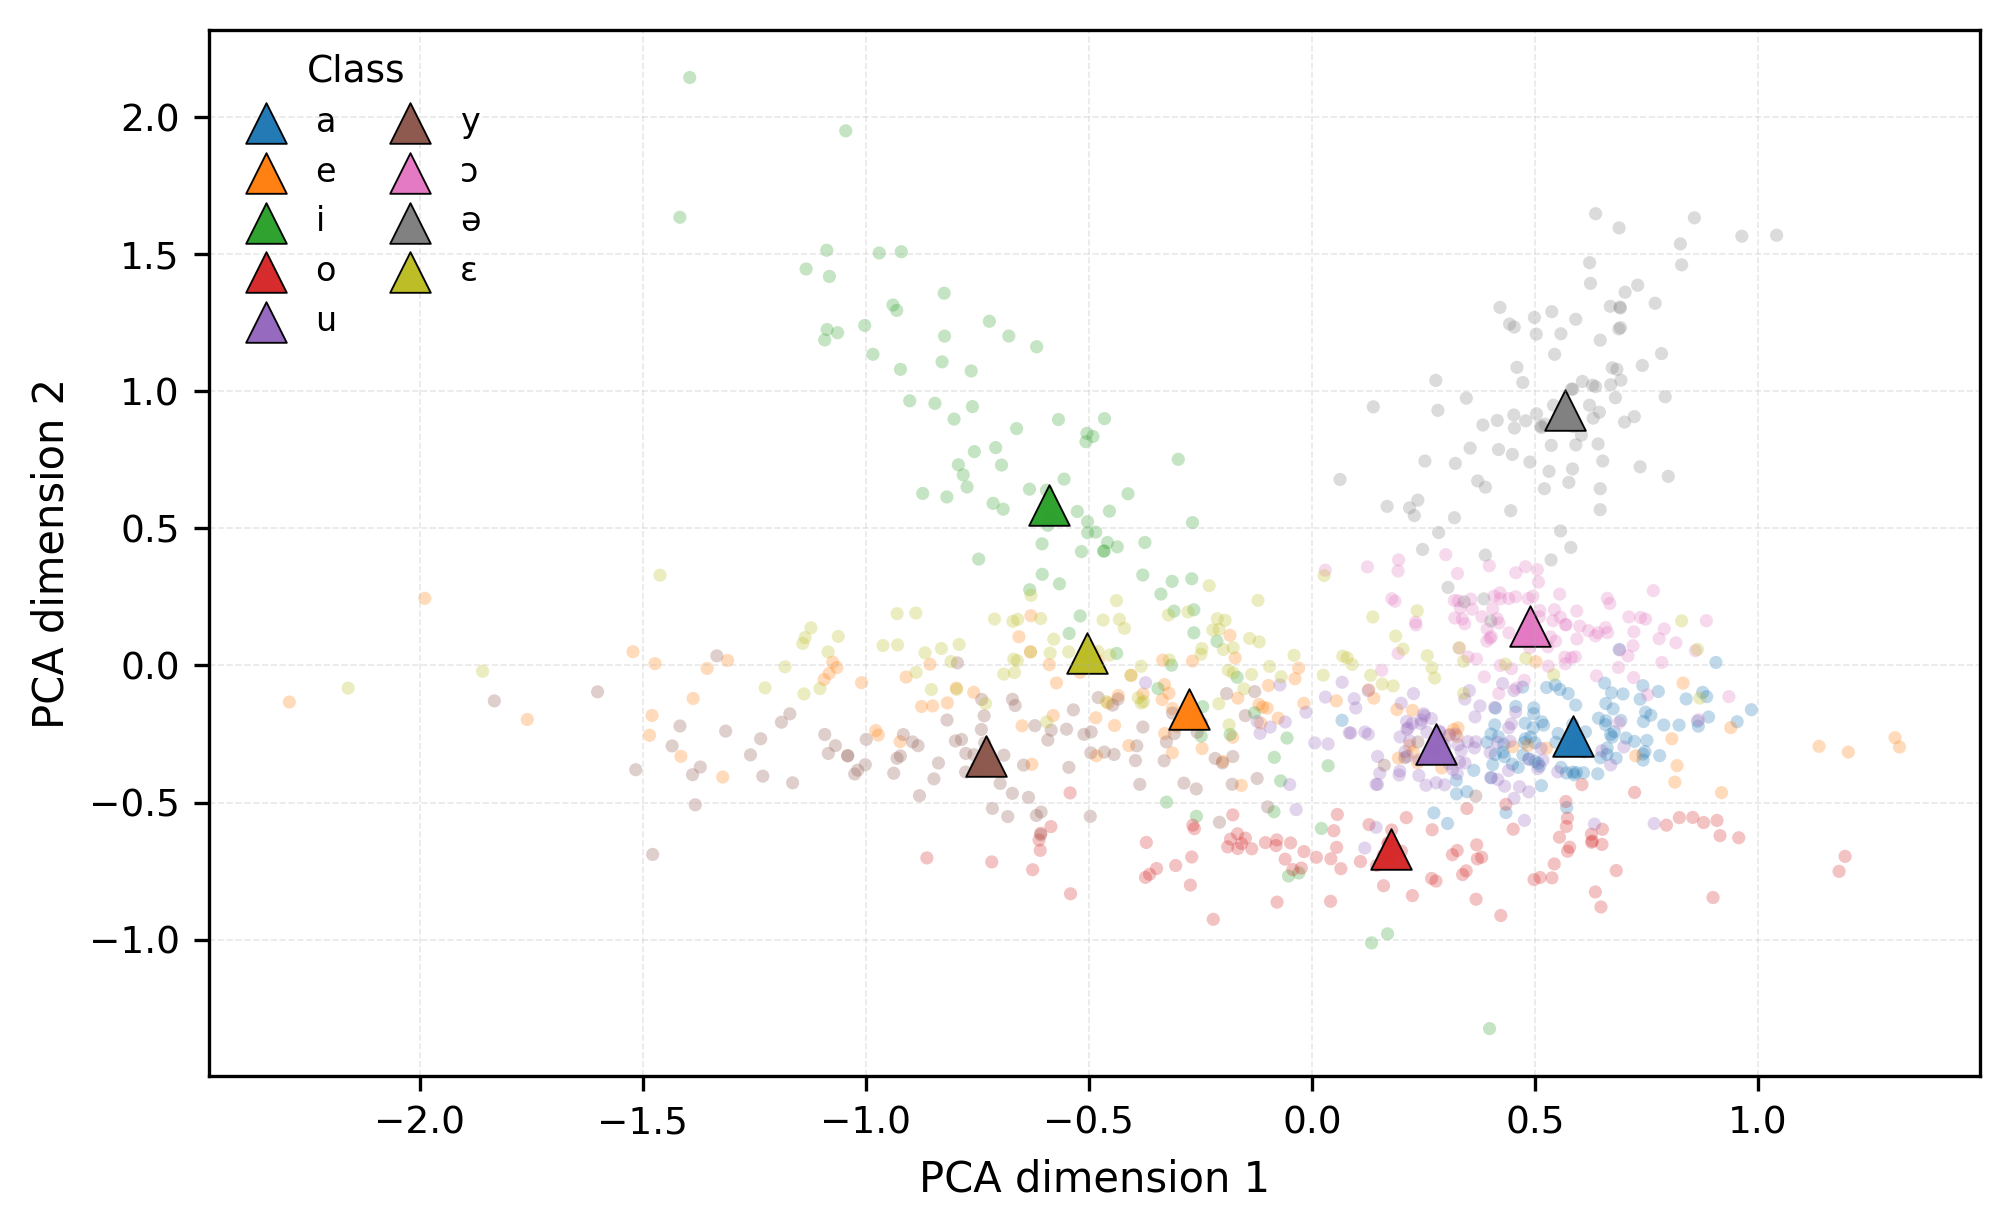

Classes: ['a', 'e', 'i', 'o', 'u', 'y', 'ɔ', 'ə', 'ɛ']
Number of classes: 9
Sampled points per class: 100
Total sampled points: 900
Number of triangle centers: 9
PCA explained variance ratio: [0.26299323 0.19128575]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA


# =========================
# 1. Configuration
# =========================

INPUT_CSV = Path("/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/mechanism_qingyang/csv/memory_trajectory.csv")
OUTPUT_DIR = Path("/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 每个类别采样点数
N_PER_CLASS = 100

# 论文风格参数
DPI = 300
FIGSIZE = (6.8, 4.2)   # 适合双栏论文宽度
FONT_LABEL = 10
FONT_TICK = 9
FONT_LEGEND = 8
FONT_LEGEND_TITLE = 9

# 点样式
SAMPLED_SIZE = 10
CENTER_SIZE = 95
SAMPLED_ALPHA = 0.28
CENTER_ALPHA = 0.98

SHOW_FIG = True
RANDOM_SEED = 42


# =========================
# 2. Load data
# =========================

mem = pd.read_csv(INPUT_CSV)

feat_cols = [c for c in mem.columns if c.startswith("f")]
if len(feat_cols) == 0:
    raise ValueError("No feature columns starting with 'f' found in memory_trajectory.csv")


def normalize_memory_type(x):
    x = str(x).lower()
    if "global" in x:
        return "Global memory"
    if "support" in x:
        return "Support candidate"
    if "episode" in x:
        return "Episode memory"
    return str(x)


mem["memory_type_pretty"] = mem["memory_type"].map(normalize_memory_type)

# 这里只用 episode memory 画图
ep = mem[mem["memory_type_pretty"] == "Episode memory"].copy()

if ep.empty:
    raise ValueError("No episode memory rows found in the CSV file.")


# =========================
# 3. PCA projection
# =========================

X = ep[feat_cols].values
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X)

ep["x1"] = Z[:, 0]
ep["x2"] = Z[:, 1]


# =========================
# 4. Generate dense sampled points
# =========================

classes = sorted(ep["class"].unique())
rng = np.random.default_rng(RANDOM_SEED)

sampled_rows = []
center_rows = []

for cls in classes:
    sub = ep[ep["class"] == cls][["x1", "x2"]].to_numpy()

    # 类中心
    mu = sub.mean(axis=0)

    # 类内协方差
    if sub.shape[0] > 1:
        cov = np.cov(sub.T)
    else:
        cov = np.eye(2) * 1e-3

    # 数值稳定
    cov = cov + np.eye(2) * 0.01

    # 在二维 PCA 空间中采样
    samples = rng.multivariate_normal(mu, cov, size=N_PER_CLASS)

    for i in range(N_PER_CLASS):
        sampled_rows.append({
            "class": cls,
            "x1": samples[i, 0],
            "x2": samples[i, 1],
        })

    center_rows.append({
        "class": cls,
        "x1": mu[0],
        "x2": mu[1],
    })

sampled = pd.DataFrame(sampled_rows)
centers = pd.DataFrame(center_rows)


# =========================
# 5. Color mapping
# =========================

# 使用稳定、论文中常见的 tab10 调色板
cmap = plt.get_cmap("tab10")
class_to_color = {cls: cmap(i % 10) for i, cls in enumerate(classes)}


# =========================
# 6. Plot
# =========================

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

# 先画浅色采样点
for cls in classes:
    pts = sampled[sampled["class"] == cls]
    ax.scatter(
        pts["x1"],
        pts["x2"],
        s=SAMPLED_SIZE,
        color=class_to_color[cls],
        alpha=SAMPLED_ALPHA,
        edgecolors="none",
        label="_nolegend_"
    )

# 再画深色三角形类别中心
for cls in classes:
    pts = centers[centers["class"] == cls]
    ax.scatter(
        pts["x1"],
        pts["x2"],
        s=CENTER_SIZE,
        color=class_to_color[cls],
        alpha=CENTER_ALPHA,
        edgecolor="black",
        linewidth=0.45,
        marker="^",
        label=str(cls)
    )

# 不加标题，更符合论文风格
ax.set_xlabel("PCA dimension 1", fontsize=FONT_LABEL)
ax.set_ylabel("PCA dimension 2", fontsize=FONT_LABEL)

ax.tick_params(axis="both", labelsize=FONT_TICK)

# 网格线轻一点
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.28)

# 让图例更紧凑
ax.legend(
    frameon=False,
    fontsize=FONT_LEGEND,
    title="Class",
    title_fontsize=FONT_LEGEND_TITLE,
    ncol=2,
    loc="upper left",
    handletextpad=0.5,
    columnspacing=1.2,
    borderaxespad=0.3
)

fig.tight_layout()


# =========================
# 7. Save and show
# =========================

output_path = OUTPUT_DIR / "fig_episode_memory_dense_paper_style.png"
fig.savefig(output_path, bbox_inches="tight")
print(f"Saved figure to: {output_path.resolve()}")

if SHOW_FIG:
    plt.show()

plt.close(fig)


# =========================
# 8. Optional info
# =========================

print("Classes:", classes)
print("Number of classes:", len(classes))
print("Sampled points per class:", N_PER_CLASS)
print("Total sampled points:", len(sampled))
print("Number of triangle centers:", len(centers))
print("PCA explained variance ratio:", pca.explained_variance_ratio_)